In [ ]:
# Standard packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Model

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split, StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
import xgboost as xgb


# Pipeline + Transformer:

from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Neural network

import torch
from torch import nn
#import cudf

# Speed up options
#%load_ext cudf.pandas
#%load_ext cuml.accel



In [90]:
# Reading in data

train = pd.read_csv('train.csv')

test = pd.read_csv('test.csv')

orig = pd.read_csv('f1_strategy_dataset_v4.csv')

changes = pd.read_csv('changes_made.csv')

scores_df = pd.read_csv('scores_df.csv')

In [91]:
# Setting up target columns and test IDs

ytrain = train['PitNextLap']

yorig = orig['PitNextLap']

test_id = test['id']

In [92]:
# Removing ID column and target

Xtrain = train.drop(columns=['id','PitNextLap'], axis = 1).copy()

Xtest = test.drop(columns = ['id'], axis = 1).copy()

Xorig = orig.drop(columns= ['Normalized_TyreLife', 'PitNextLap'], axis = 1).copy()

# Data cleaning #

In [93]:


# Null values

Xtrain.info(), Xtest.info() , Xorig.info() # No null values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
dtypes: float64(6), int64

(None, None, None)

In [94]:
num_cols = Xtrain.select_dtypes(['int','float']).columns.to_list()
num_cols

['Year',
 'PitStop',
 'LapNumber',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change']

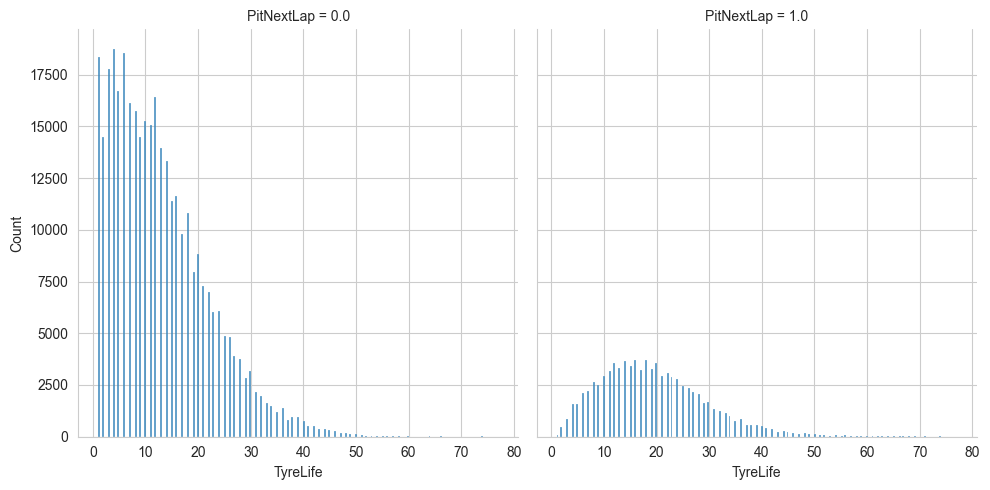

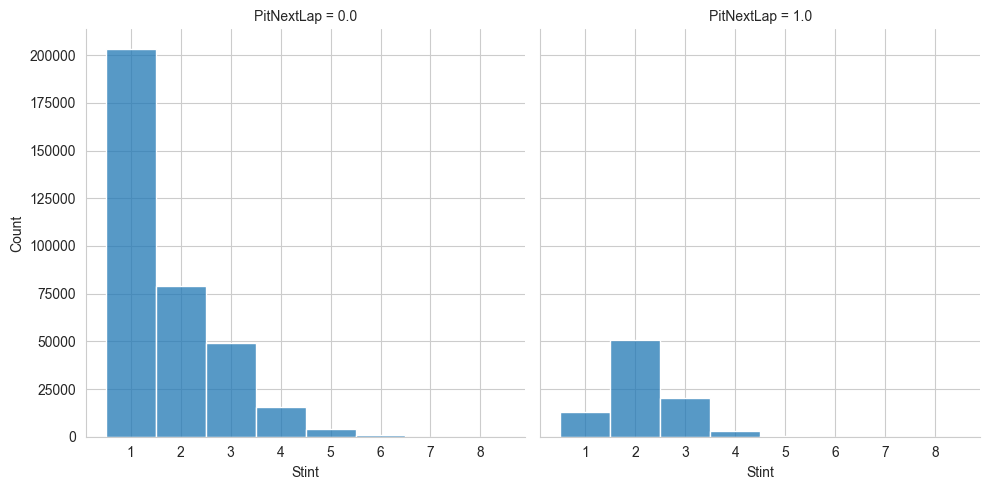

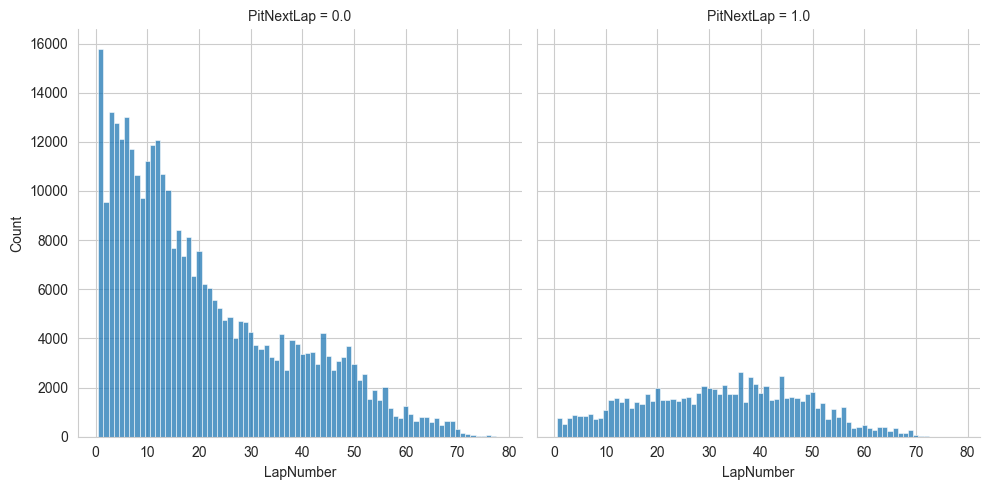

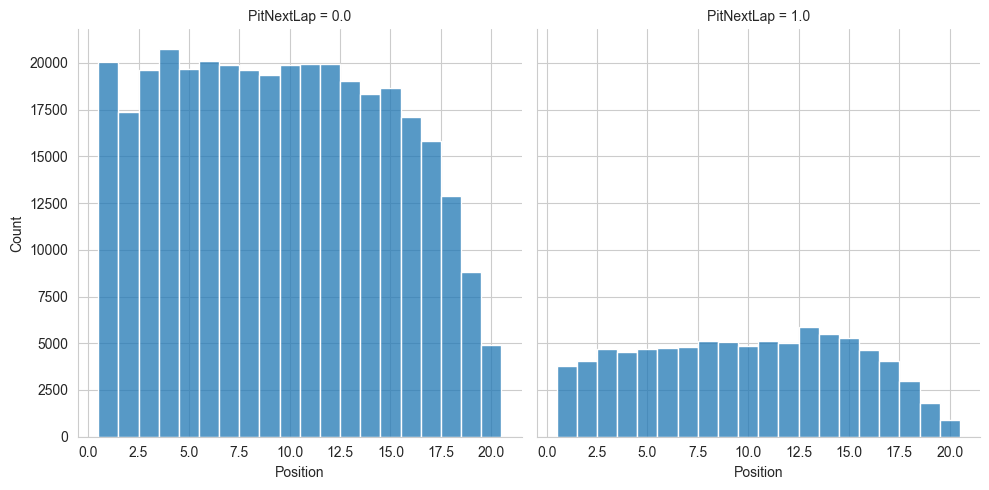

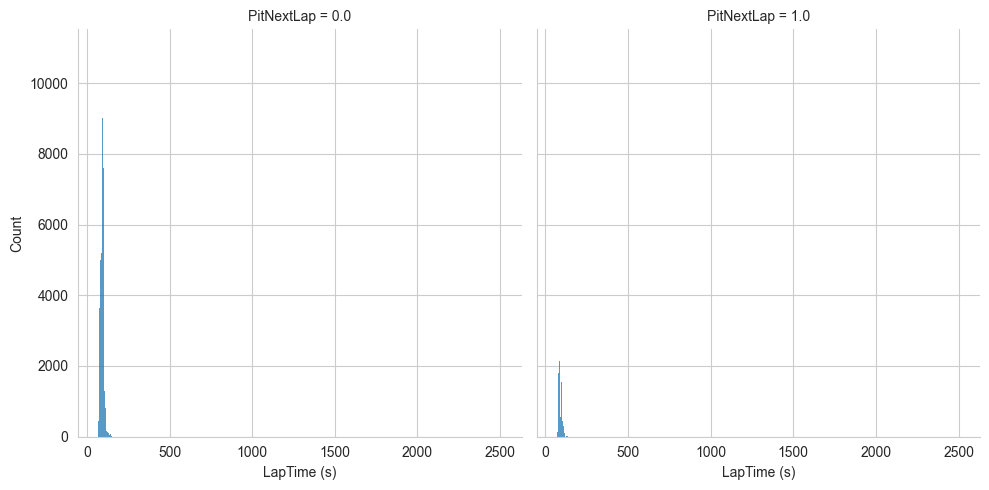

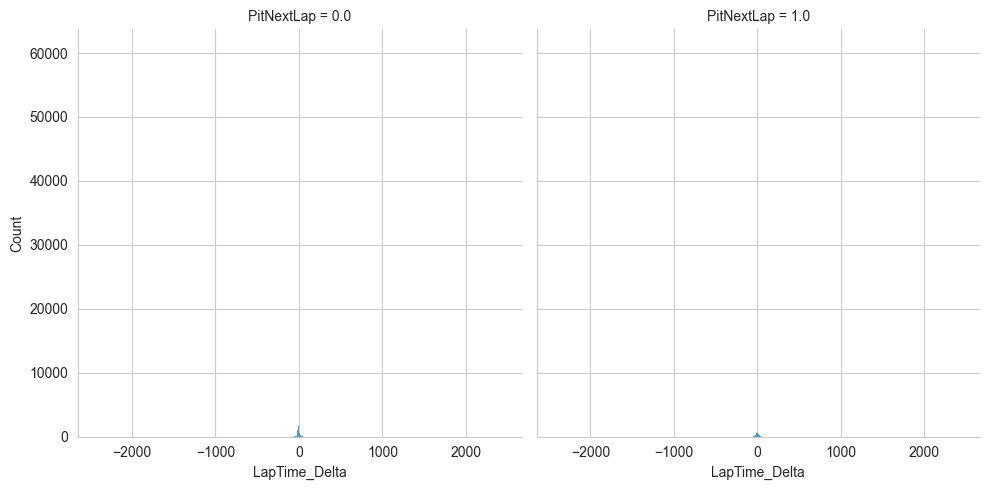

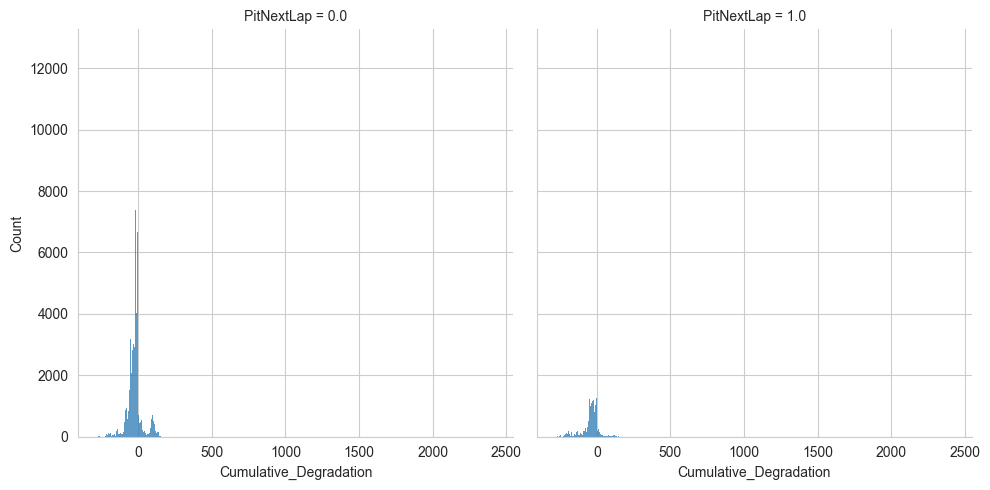

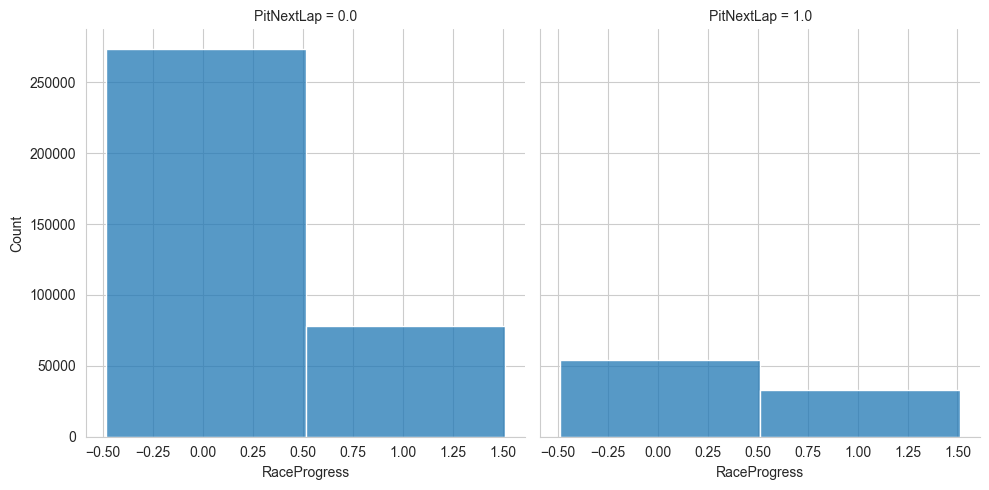

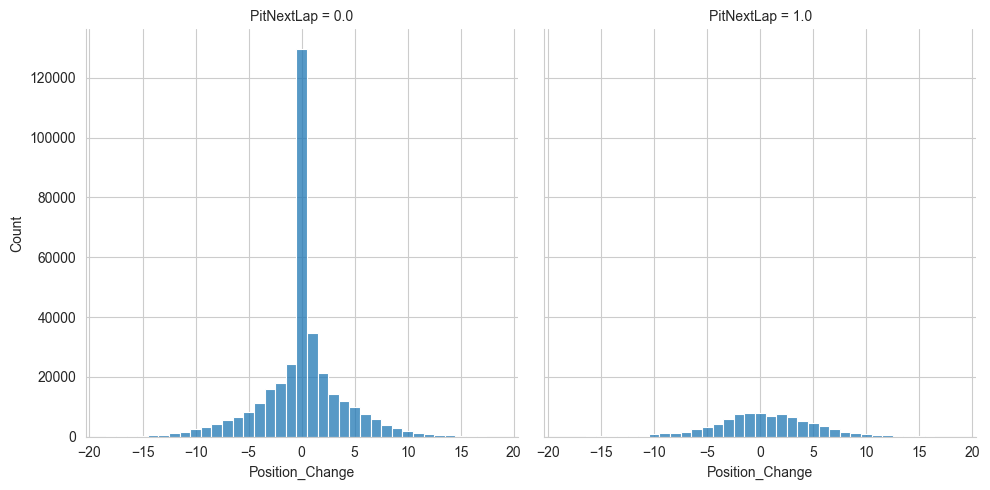

In [95]:
# Understanding if any feature outliers have a significant impact on target

sns.displot(
    data=train,
    x = 'TyreLife',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd'
)

sns.displot(
    data=train,
    x = 'Stint',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'LapNumber',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)


sns.displot(
    data=train,
    x = 'Position',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'LapTime (s)',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd'
)

sns.displot(
    data=train,
    x = 'LapTime_Delta',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd'
)


sns.displot(
    data=train,
    x = 'Cumulative_Degradation',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'RaceProgress',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)

sns.displot(
    data=train,
    x = 'Position_Change',
    col = 'PitNextLap',
    height = 5,
    bins = 'fd',
    discrete = True
)


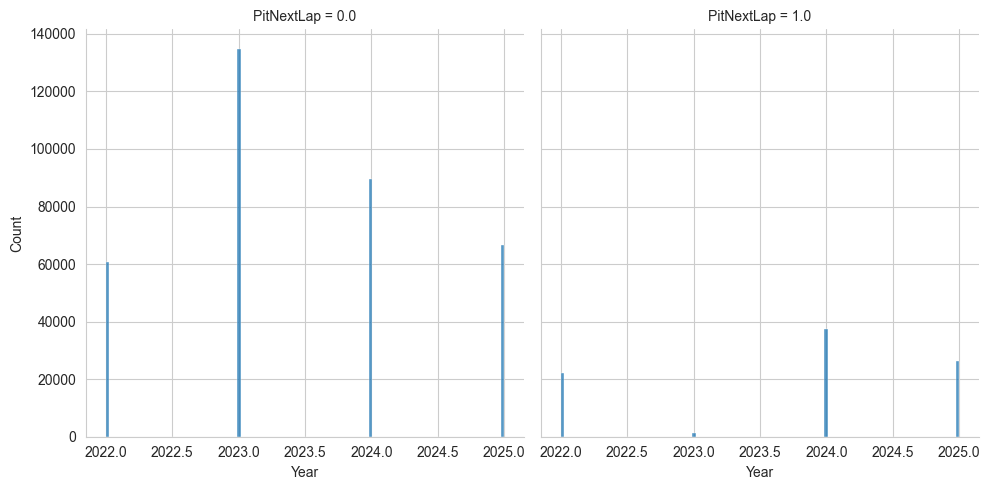

In [96]:
sns.displot(
    x = 'Year',
    data = train,
    col = 'PitNextLap'
)

In [97]:
# Summary statisitcs
Xtrain[num_cols].describe()


,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000


In [98]:
# Winsorization
cols_to_remove = ['PitStop','PitNextLap'] # Binary columns that contain imbalanced responses

def num_outliers(df, choice):

    """
    The function applies the moethod of winsorization to outliers. Choice is a boolean repsonse. True applies the method to the data
    frame. Fasle just prints out any information you would like to know about the data frame 
    """

    df_new = df.copy()

    num_cols = df_new.select_dtypes(['int','float']).columns.to_list()

    num_cols = list(set(num_cols) - set(cols_to_remove))

    df_new[num_cols] = df_new[num_cols].astype('float')

    for col in num_cols:

        q1 = np.quantile(df_new[col], 0.25)

        q3 = np.quantile(df_new[col], 0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr

        upper = q3 + 1.5 * iqr

        # Mask returns true/falses where data column meets outlier criteria

        mask = (df_new[col] < lower) | (df_new[col] > upper)

        low_mask = (df_new[col] < lower)

        high_mask = (df_new[col] > upper)

        n_outliers = mask.sum()

        print(f'{col} has {n_outliers} outliers')

        if choice == True: # Winsorization 

            df_no_outliers = df_new.loc[~mask]

            df_out_low = df_new.loc[low_mask]

            df_out_high = df_new.loc[high_mask]

            df_out_high.loc[:, col] = upper

            df_out_low.loc[:, col] = lower

            df_new = pd.concat([df_no_outliers, df_out_high, df_out_low], axis = 0).sort_index()
        else:
            print('No changes made to dataframe')



    print(f'Shape of new data frame {df_new.shape} | Shape of old data frame {df.shape}')


    return df_new



In [99]:
Xtrain_outliers = num_outliers(Xtrain, True)
print('//////////')
Xtest_outliers = num_outliers(Xtest, True)
print('//////////')
Xorig_outliers = num_outliers(Xorig, True)

TyreLife has 5711 outliers
LapTime_Delta has 58900 outliers
RaceProgress has 0 outliers
Position has 0 outliers
LapNumber has 16 outliers
Position_Change has 61180 outliers
Stint has 24078 outliers
Cumulative_Degradation has 49869 outliers
LapTime (s) has 5905 outliers
Year has 0 outliers
Shape of new data frame (439140, 14) | Shape of old data frame (439140, 14)
//////////
TyreLife has 2494 outliers
LapTime_Delta has 25068 outliers
RaceProgress has 0 outliers
Position has 0 outliers
LapNumber has 4 outliers
Position_Change has 26289 outliers
Stint has 10266 outliers
Cumulative_Degradation has 21168 outliers
LapTime (s) has 2531 outliers
Year has 0 outliers
Shape of new data frame (188165, 14) | Shape of old data frame (188165, 14)
//////////
TyreLife has 2360 outliers
LapTime_Delta has 11011 outliers
RaceProgress has 0 outliers
LapNumber has 0 outliers
Position has 0 outliers
Position_Change has 5526 outliers
Stint has 59 outliers
Cumulative_Degradation has 14813 outliers
LapTime (s) 

In [100]:
# Seeing how the distribution of the numerical columns changes after function is applied
Xtrain_outliers[num_cols].describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105887,1.747386,14.064292,9.630339,90.694495,-3.198990,-25.770644,0.337661,0.179501
std,1.024930,0.342915,16.958189,0.842466,9.470867,5.278770,10.909845,9.245325,36.721484,0.253277,3.166100
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-22.382500,-107.117125,0.012821,-5.500000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000
max,2025.000000,1.000000,76.500000,3.500000,41.000000,20.000000,122.246000,13.613500,54.351875,1.000000,6.500000


In [101]:
cat_cols = Xtrain_outliers.select_dtypes('object').columns.to_list()
cat_cols

['Driver', 'Compound', 'Race']

In [102]:
# Identifying any potential columns with categorical outliers or anomalies, mis-entries etc. and what columns to encode
Xtrain_outliers[cat_cols].describe()

,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462


In [103]:
Xtrain_outliers['Driver'].unique()

array(['D109', 'D086', 'ZON', 'SPE', 'D019', 'D012', 'D104', 'D082',
       'BEL', 'YAM', 'MAS', 'D010', 'D063', 'D196', 'D132', 'D047', 'PRO',
       'D066', 'DRA', 'PEA', 'HAD', 'HUL', 'COU', 'D036', 'D205', 'BER',
       'VIL', 'GUT', 'TUR', 'D089', 'D055', 'D189', 'D071', 'DAM', 'D144',
       'D384', 'D263', 'D117', 'D120', 'D054', 'D184', 'D214', 'IDE',
       'D216', 'D101', 'D160', 'WIL', 'CAR', 'D251', 'D106', 'D083',
       'WAR', 'D065', 'MIN', 'D293', 'BIA', 'D125', 'D073', 'ALE', 'D007',
       'D009', 'D202', 'NOR', 'FRE', 'D057', 'D177', 'D049', 'ALG', 'SUT',
       'D312', 'D159', 'D219', 'ROS', 'D166', 'D218', 'D045', 'D197',
       'GIO', 'DIR', 'D138', 'WEB', 'D070', 'D097', 'LEC', 'D050', 'D369',
       'HYD', 'D355', 'D032', 'D292', 'BEA', 'D001', 'D232', 'D211',
       'DIN', 'D157', 'NAK', 'TAY', 'STR', 'D325', 'D028', 'RIC', 'ZHO',
       'GAS', 'D041', 'D014', 'D283', 'WUR', 'D061', 'D281', 'D046',
       'TSU', 'D170', 'D122', 'D210', 'D191', 'D074', 'SHA', 'D

In [104]:
Xtrain_outliers['Driver'].str.startswith('D1')

0          True
1         False
2         False
3         False
4         False
          ...  
439135    False
439136    False
439137    False
439138    False
439139    False
Name: Driver, Length: 439140, dtype: bool

In [105]:
# Categorical outliers

def cat_outliers(df):

    df_new = df.copy()

    for i in range(10):

        df_new['Driver'] = df_new['Driver'].apply(lambda x: f'D{i}00s' if x.startswith(f'D{i}') else x)


    print('All categorical outliers were removed')

    return df_new




In [106]:
Xtrain_cat_outliers = cat_outliers(Xtrain_outliers)
Xtest_cat_outliers = cat_outliers(Xtest_outliers)
Xorig_cat_outliers = cat_outliers(Xorig_outliers)

All categorical outliers were removed
All categorical outliers were removed
All categorical outliers were removed


# Feature engineering #

In [107]:
# Categorical feature engineering

def cat_fe(df):

    df_new = df.copy()

    for i, c1 in enumerate(cat_cols):
        for j, c2 in enumerate(cat_cols):
            if i < j:

                df_new[f'BI_Combin_{c1}_{c2}'] = df_new[c1].astype(str) + "_" + df_new[c2].astype(str)

    for i, c1 in enumerate(cat_cols):
        for j, c2 in enumerate(cat_cols):
            for k, c3 in enumerate(cat_cols):
                if i < j:
                    if j < k:

                        df_new[f'TRI_Combin_{c1}_{c2}_{c3}'] = df_new[c1].astype(str) + "_" + df_new[c2].astype(str) + "_" + df_new[c3].astype(str)
    

                
    print('Categorical Feature Engineering complete')

    return df_new


In [108]:
Xtrain_cat = cat_fe(Xtrain_cat_outliers)

Xtest_cat = cat_fe(Xtest_cat_outliers)

Xorig_cat = cat_fe(Xorig_cat_outliers)

Categorical Feature Engineering complete
Categorical Feature Engineering complete
Categorical Feature Engineering complete


In [109]:
Xtrain_cat.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'BI_Combin_Driver_Compound', 'BI_Combin_Driver_Race',
       'BI_Combin_Compound_Race', 'TRI_Combin_Driver_Compound_Race'],
      dtype='object')

In [110]:
Xtrain_cat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 439140 entries, 0 to 439139
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Driver                           439140 non-null  object 
 1   Compound                         439140 non-null  object 
 2   Race                             439140 non-null  object 
 3   Year                             439140 non-null  float64
 4   PitStop                          439140 non-null  int64  
 5   LapNumber                        439140 non-null  float64
 6   Stint                            439140 non-null  float64
 7   TyreLife                         439140 non-null  float64
 8   Position                         439140 non-null  float64
 9   LapTime (s)                      439140 non-null  float64
 10  LapTime_Delta                    439140 non-null  float64
 11  Cumulative_Degradation           439140 non-null  float64
 12  RacePro

In [111]:
# Numerical feature engineering

def num_fe(df):

    df_new = df.copy()

    df_new['Lap_x_Delta'] = df_new['LapTime (s)'] * df_new['LapTime_Delta']

    df_new['Average_Position_Change'] = (df_new['Position'] + df_new['Position_Change'])/2

    df_new['TyreLife_Left'] = df_new['TyreLife']/(df_new['LapNumber'])

    df_new['Stint_Per_Year'] =   df_new['Stint']/df_new['Year']

    df_new['Cumulative_Degradation_Outliers'] = np.absolute(df_new['Cumulative_Degradation'] - df_new['Cumulative_Degradation'].mean())

    df_new['LapTimeDelta_Per_Year'] = df_new['LapTime_Delta']/df_new['Year']

    df_new['CD_Per_Year'] = df_new['Cumulative_Degradation']/df_new['Year']

    df_new['Tyre_To_Progress'] = df_new['TyreLife'] * df_new['RaceProgress']

    df_new['Tyre_To_Lap'] = df_new['TyreLife'] * df_new['LapNumber']

    df_new['Stint_Per_Delta'] = df_new['Stint']/(df_new['LapTime_Delta'] + df_new['LapTime_Delta'].min())
    




    print('Numerical Feature Engineering is complete')


    return df_new



In [112]:
Xtrain_num = num_fe(Xtrain_cat)

Xtest_num = num_fe(Xtest_cat)

Xorig_num = num_fe(Xorig_cat)

Numerical Feature Engineering is complete
Numerical Feature Engineering is complete
Numerical Feature Engineering is complete


In [113]:
# Removing rows containing races not included in test or training set

mask = (Xorig_num['Race'] == 'Pre-Season Test') | (Xorig_num['Race'] == 'Pre-Season Track Session' )

Xorig_num = Xorig_num[~mask].reset_index(drop=True)

yorig = yorig.iloc[Xorig_num.index]


In [114]:
top_num_cols = ['TyreLife','Stint', 'RaceProgress']

In [115]:
# Frequency encoding
def freq_encoder(df):

    df_new = df.copy()

    cat_cols = df_new.select_dtypes('object').columns.to_list()

    drop_cols = list(set(cat_cols) - set(['Compound','Driver','Race']))

    for col in cat_cols:

        freq_tab = pd.concat([Xtrain_num[col], Xtest_num[col], Xorig_num[col]]).value_counts()

        df_new[f'Freq_{col}'] = df_new[col].map(freq_tab).fillna(0).astype(float)

    print('Frequency encoding is complete')

    df_new = df_new.drop(columns = drop_cols, axis = 1)

    return df_new



In [116]:
Xtrain_freq = freq_encoder(Xtrain_num)

Xtest_freq = freq_encoder(Xtest_num)

Xorig_freq = freq_encoder(Xorig_num)

Frequency encoding is complete
Frequency encoding is complete
Frequency encoding is complete


In [117]:


num_pro = Xtrain_freq.select_dtypes(['int','float']).columns.to_list()

ohe_pro = ['Compound']

te_pro = ['Driver', 'Compound', 'Year', 'Race']


num_pro

['Year',
 'PitStop',
 'LapNumber',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change',
 'Lap_x_Delta',
 'Average_Position_Change',
 'TyreLife_Left',
 'Stint_Per_Year',
 'Cumulative_Degradation_Outliers',
 'LapTimeDelta_Per_Year',
 'CD_Per_Year',
 'Tyre_To_Progress',
 'Tyre_To_Lap',
 'Stint_Per_Delta',
 'Freq_Driver',
 'Freq_Compound',
 'Freq_Race',
 'Freq_BI_Combin_Driver_Compound',
 'Freq_BI_Combin_Driver_Race',
 'Freq_BI_Combin_Compound_Race',
 'Freq_TRI_Combin_Driver_Compound_Race']

# Preprocessing #

In [118]:
preprocessor = ColumnTransformer([
    ('Num', Pipeline([
        ('scaler', StandardScaler())
    ]), num_pro),

    ('Cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ]), ohe_pro)
])

def data_prep(df):

    df_new = df.copy()

    ImputedX = preprocessor.fit_transform(Xtrain_freq)

    colnames = preprocessor.get_feature_names_out()

    df_imputed = preprocessor.transform(df_new)

    df_final = pd.DataFrame(df_imputed, columns=colnames, index=df.index)

    df_final = df_final.merge(df.loc[:, ['Race', 'Year','Compound','Driver']].astype('category'), left_index=True, right_index=True)


    print('Data preprocessing is complete')

    return df_final

In [119]:
Xtrain_pre = data_prep(Xtrain_freq)

Xtest_pre = data_prep(Xtest_freq)

Xorig_pre = data_prep(Xorig_freq)

Data preprocessing is complete
Data preprocessing is complete
Data preprocessing is complete


In [120]:
te_features = te_pro

In [121]:
Xtrain_pre.dtypes

Num__Year                                     float64
Num__PitStop                                  float64
Num__LapNumber                                float64
Num__Stint                                    float64
Num__TyreLife                                 float64
Num__Position                                 float64
Num__LapTime (s)                              float64
Num__LapTime_Delta                            float64
Num__Cumulative_Degradation                   float64
Num__RaceProgress                             float64
Num__Position_Change                          float64
Num__Lap_x_Delta                              float64
Num__Average_Position_Change                  float64
Num__TyreLife_Left                            float64
Num__Stint_Per_Year                           float64
Num__Cumulative_Degradation_Outliers          float64
Num__LapTimeDelta_Per_Year                    float64
Num__CD_Per_Year                              float64
Num__Tyre_To_Progress       

In [122]:
Xtest_pre.shape, Xorig_pre.shape, Xtrain_pre.shape, ytrain.shape, yorig.shape

((188165, 36), (99680, 36), (439140, 36), (439140,), (99680,))

In [123]:
Xtrain_final = pd.concat([Xtrain_pre,Xorig_pre], axis = 0, ignore_index=True)

ytrain_final = pd.concat([ytrain,yorig], axis = 0, ignore_index=True)
Xtrain_final.shape, ytrain_final.shape

((538820, 36), (538820,))

In [124]:
# PCA feature engineering 

def pca_fe(df):

    df_new = df.copy()

    pca_cols = df_new.columns[df_new.columns.str.startswith('Num')].to_list()

    pca = PCA(n_components=0.90, random_state=42)

    X_pca = pca.fit(df_new[pca_cols])

    loadings = X_pca.components_.T 

    loadings_df = pd.DataFrame(loadings, 
                           columns = [f'PC{i+1}' for i in range(X_pca.explained_variance_ratio_.shape[0])],
                           index=X_pca.feature_names_in_)
    
    for i in range(1):

        pc = []

        for col in loadings_df.index:

            df_new[f'PC{i+1}_{col}'] = df_new[col] * loadings_df.loc[col][f'PC{i+1}']

            pc.append(f'PC{i+1}_{col}')

        df_new[f'PC{i+1}'] = df_new[pc].sum(axis = 1)

        df_new = df_new.drop(columns = pc, axis = 1)

        del pc

    # Explained variation amongst variables
    print(f'The variance explained by PC1 {X_pca.explained_variance_ratio_[0] : .2%}')
    print(f'The variance explained by PC2 {X_pca.explained_variance_ratio_[1] : .2%}')
    print(f'The variance explained by PC3 {X_pca.explained_variance_ratio_[2] : .2%}')
    print('...')
    print(f'The variance explained by PC{X_pca.explained_variance_ratio_.shape[0]} {X_pca.explained_variance_ratio_[X_pca.explained_variance_ratio_.shape[0]-1] : .2%}')

    # Noise level of components
    print(f'The variance explained by last 2 components is {X_pca.explained_variance_ratio_[-2:].sum() : .2%}')


    print('PC feature engineering complete')
    print('///////////////////////////////')


    return df_new



In [125]:
Xtrain_final = pca_fe(Xtrain_final)

Xtest_pre = pca_fe(Xtest_pre)

Xtrain_final.shape, Xtest_pre.shape

The variance explained by PC1  26.91%
The variance explained by PC2  15.36%
The variance explained by PC3  9.69%
...
The variance explained by PC11  3.12%
The variance explained by last 2 components is  6.40%
PC feature engineering complete
///////////////////////////////
The variance explained by PC1  22.22%
The variance explained by PC2  14.76%
The variance explained by PC3  11.90%
...
The variance explained by PC11  2.83%
The variance explained by last 2 components is  6.79%
PC feature engineering complete
///////////////////////////////


((538820, 37), (188165, 37))

In [126]:
te_features

['Driver', 'Compound', 'Year', 'Race']

# XgBoost Classifier #

In [127]:
Xtrain_final[te_features] = Xtrain_final[te_features].astype('category')

Xtest_pre[te_features] = Xtest_pre[te_features].astype('category')

In [128]:
# Device agnostics

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [129]:
# Testing

# OOF predictions
oof_preds = np.zeros(shape=(len(ytrain_final),2))

bagging_oof = np.zeros_like(test_id).astype('float64')

# Scoring
auc_score = pd.DataFrame(columns=['auc_score'])

# Group Stratified K-Fold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42

)

# Train/Test

for fold,(train_idx, val_idx) in enumerate(skf.split(X = Xtrain_final,y = ytrain_final)):

    print(f'Looping through fold:{fold}')

    X_train, X_val = Xtrain_final.iloc[train_idx], Xtrain_final.iloc[val_idx]

    y_train, y_val = ytrain_final.iloc[train_idx], ytrain_final.iloc[val_idx]

    # Target encoding 

    te = TargetEncoder( cv = 5, target_type='binary', random_state=42, smooth='auto')

    X_train_te = te.fit_transform(X_train[te_features], y_train)

    X_val_te = te.transform(X_val[te_features])

    X_test = Xtest_pre.copy()

    Xtest_te = te.transform(X_test[te_features])

    te_cols = []

    for var in te_features:
        for class_id in range(1):

            te_cols.append(f'TE_{var}_class{class_id}')


    X_train[te_cols] = X_train_te

    X_val[te_cols] = X_val_te

    X_test[te_cols] = Xtest_te

    X_train = X_train.drop(columns = te_features, axis = 1)

    X_val = X_val.drop(columns = te_features, axis = 1)

    X_test = X_test.drop(columns = te_features, axis = 1)

    # Scale classes 
    spw = (len(y_train) - np.sum(y_train))/np.sum(y_train)

    # Model
    model = xgb.XGBClassifier(n_estimators = 300,
                              learning_rate = 0.1,
                              n_jobs = -1,
                              scale_pos_weight = spw,
                              objective = 'binary:logistic',
                              random_state = 42)
    

    # Train
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose = 1)

    # Predictions 

    y_preds = model.predict_proba(X_val)[:, 1]

    oof_preds[val_idx] = model.predict_proba(X_val) # In line with the correct indices 

    bagging_oof += model.predict_proba(X_test)[:,1]/5

    # AUC
    score = roc_auc_score(y_val, y_preds)


    auc_score.loc[fold, 'auc_score'] = score

    del Xtest_te, X_val_te, X_train_te, model, X_test



oof_score = roc_auc_score(ytrain_final, oof_preds[:, 1])
print(f'Out of fold predicition auc score: {oof_score}')


Looping through fold:0


C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

[0]	validation_0-logloss:0.63845
[1]	validation_0-logloss:0.59430
[2]	validation_0-logloss:0.55764
[3]	validation_0-logloss:0.52731
[4]	validation_0-logloss:0.50185
[5]	validation_0-logloss:0.48019
[6]	validation_0-logloss:0.46184
[7]	validation_0-logloss:0.44620
[8]	validation_0-logloss:0.43277
[9]	validation_0-logloss:0.42087
[10]	validation_0-logloss:0.41093
[11]	validation_0-logloss:0.40225
[12]	validation_0-logloss:0.39481
[13]	validation_0-logloss:0.38805
[14]	validation_0-logloss:0.38211
[15]	validation_0-logloss:0.37722
[16]	validation_0-logloss:0.37288
[17]	validation_0-logloss:0.36900
[18]	validation_0-logloss:0.36564
[19]	validation_0-logloss:0.36285
[20]	validation_0-logloss:0.36006
[21]	validation_0-logloss:0.35763
[22]	validation_0-logloss:0.35532
[23]	validation_0-logloss:0.35343
[24]	validation_0-logloss:0.35185
[25]	validation_0-logloss:0.35027
[26]	validation_0-logloss:0.34874
[27]	validation_0-logloss:0.34749
[28]	validation_0-logloss:0.34645
[29]	validation_0-loglos

C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

[0]	validation_0-logloss:0.63837
[1]	validation_0-logloss:0.59396
[2]	validation_0-logloss:0.55730
[3]	validation_0-logloss:0.52705
[4]	validation_0-logloss:0.50148
[5]	validation_0-logloss:0.47988
[6]	validation_0-logloss:0.46132
[7]	validation_0-logloss:0.44563
[8]	validation_0-logloss:0.43180
[9]	validation_0-logloss:0.42029
[10]	validation_0-logloss:0.41020
[11]	validation_0-logloss:0.40173
[12]	validation_0-logloss:0.39413
[13]	validation_0-logloss:0.38763
[14]	validation_0-logloss:0.38159
[15]	validation_0-logloss:0.37670
[16]	validation_0-logloss:0.37225
[17]	validation_0-logloss:0.36822
[18]	validation_0-logloss:0.36461
[19]	validation_0-logloss:0.36171
[20]	validation_0-logloss:0.35889
[21]	validation_0-logloss:0.35639
[22]	validation_0-logloss:0.35394
[23]	validation_0-logloss:0.35193
[24]	validation_0-logloss:0.35017
[25]	validation_0-logloss:0.34848
[26]	validation_0-logloss:0.34717
[27]	validation_0-logloss:0.34599
[28]	validation_0-logloss:0.34471
[29]	validation_0-loglos

...

[0]	validation_0-logloss:0.63845
[1]	validation_0-logloss:0.59388
[2]	validation_0-logloss:0.55744
[3]	validation_0-logloss:0.52686
[4]	validation_0-logloss:0.50135
[5]	validation_0-logloss:0.47988
[6]	validation_0-logloss:0.46143
[7]	validation_0-logloss:0.44565
[8]	validation_0-logloss:0.43210
[9]	validation_0-logloss:0.42049
[10]	validation_0-logloss:0.41047
[11]	validation_0-logloss:0.40169
[12]	validation_0-logloss:0.39410
[13]	validation_0-logloss:0.38754
[14]	validation_0-logloss:0.38187
[15]	validation_0-logloss:0.37671
[16]	validation_0-logloss:0.37217
[17]	validation_0-logloss:0.36833
[18]	validation_0-logloss:0.36498
[19]	validation_0-logloss:0.36197
[20]	validation_0-logloss:0.35908
[21]	validation_0-logloss:0.35659
[22]	validation_0-logloss:0.35449
[23]	validation_0-logloss:0.35246
[24]	validation_0-logloss:0.35074
[25]	validation_0-logloss:0.34912
[26]	validation_0-logloss:0.34779
[27]	validation_0-logloss:0.34648
[28]	validation_0-logloss:0.34532
[29]	validation_0-loglos

C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

[0]	validation_0-logloss:0.63842
[1]	validation_0-logloss:0.59393
[2]	validation_0-logloss:0.55746
[3]	validation_0-logloss:0.52719
[4]	validation_0-logloss:0.50174
[5]	validation_0-logloss:0.48014
[6]	validation_0-logloss:0.46175
[7]	validation_0-logloss:0.44611
[8]	validation_0-logloss:0.43269
[9]	validation_0-logloss:0.42124
[10]	validation_0-logloss:0.41128
[11]	validation_0-logloss:0.40243
[12]	validation_0-logloss:0.39507
[13]	validation_0-logloss:0.38828
[14]	validation_0-logloss:0.38265
[15]	validation_0-logloss:0.37756
[16]	validation_0-logloss:0.37323
[17]	validation_0-logloss:0.36946
[18]	validation_0-logloss:0.36610
[19]	validation_0-logloss:0.36303
[20]	validation_0-logloss:0.36032
[21]	validation_0-logloss:0.35806
[22]	validation_0-logloss:0.35594
[23]	validation_0-logloss:0.35398
[24]	validation_0-logloss:0.35223
[25]	validation_0-logloss:0.35075
[26]	validation_0-logloss:0.34933
[27]	validation_0-logloss:0.34804
[28]	validation_0-logloss:0.34679
[29]	validation_0-loglos

C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[te_cols] = X_train_te
C:\Users\taled\AppData\Local\Temp\ipykernel_9844\2539694215.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

[0]	validation_0-logloss:0.63844
[1]	validation_0-logloss:0.59429
[2]	validation_0-logloss:0.55761
[3]	validation_0-logloss:0.52738
[4]	validation_0-logloss:0.50195
[5]	validation_0-logloss:0.48035
[6]	validation_0-logloss:0.46195
[7]	validation_0-logloss:0.44631
[8]	validation_0-logloss:0.43277
[9]	validation_0-logloss:0.42112
[10]	validation_0-logloss:0.41084
[11]	validation_0-logloss:0.40209
[12]	validation_0-logloss:0.39468
[13]	validation_0-logloss:0.38811
[14]	validation_0-logloss:0.38233
[15]	validation_0-logloss:0.37715
[16]	validation_0-logloss:0.37276
[17]	validation_0-logloss:0.36900
[18]	validation_0-logloss:0.36558
[19]	validation_0-logloss:0.36255
[20]	validation_0-logloss:0.36001
[21]	validation_0-logloss:0.35743
[22]	validation_0-logloss:0.35530
[23]	validation_0-logloss:0.35338
[24]	validation_0-logloss:0.35162
[25]	validation_0-logloss:0.35002
[26]	validation_0-logloss:0.34863
[27]	validation_0-logloss:0.34744
[28]	validation_0-logloss:0.34618
[29]	validation_0-loglos

In [130]:
auc_score

,auc_score
0,0.949818
1,0.950675
2,0.951241
3,0.949946
4,0.949966


In [131]:
model_number = 42


scores_df.loc[model_number, 'Mean_Fold_Score'] = np.mean(auc_score)

scores_df.loc[model_number, 'Model'] = model_number

scores_df.loc[model_number, 'OOF_Score'] = oof_score

scores_df.to_csv('scores_df.csv', index=False)

In [132]:


changes.loc[model_number, 'Model_Number'] = model_number
changes.loc[model_number, 'Changes_Made'] = 'pc1 and numerical feature engineering'

changes.to_csv('changes_made.csv', index = False)

In [133]:
scores_df

,Mean_Fold_Score,Model,OOF_Score
0,0.941352,1.0,0.941344
1,0.941823,2.0,0.941818
2,0.946881,3.0,0.946875
3,0.947004,4.0,0.946998
4,0.944170,5.0,0.944165
5,0.947004,5.0,0.946998
6,0.946926,6.0,0.946921
7,0.947004,7.0,0.946998
8,0.948078,8.0,0.948074
9,0.946858,9.0,0.946851


In [88]:
changes['Changes_Made'].tail(10)

27                           Added in pc 1 + 2 encoding
28                   Added in pc 1 + 2 + 3 + 4 encoding
29               Added in pc 1 + 2 + 3 + 4 + 5 encoding
30       Added in pc 1 + 2 + 3 + 4 + 5 + 6 + 7 encoding
31    Added in pc 1 + 2 + 3 + 4 + 5 + 6 + 7 + 8 + 9 ...
32       Reverted back to pc 1 + 2 + 3 + 4 + 5 encoding
33    Reverted back to pc 1 + 2 + 3 + 4 + 5 + 6 enco...
40                                       Removed pc 3-6
41                   Removed numerical feautre encoding
42                           Added in all available pcs
Name: Changes_Made, dtype: object

In [ ]:
test_oof = pd.DataFrame(bagging_oof, columns = ['PitNextLap'])
test_oof.shape

In [ ]:
mask = (test_oof['PitNextLap'] <= 0.7) & (test_oof['PitNextLap'] >= 0.4)
mask

In [ ]:
unconfident_preds = Xtest_freq[mask]

In [ ]:
unconfident_preds.describe(include='object')

In [ ]:
submission = pd.concat([test_id,test_oof['PitNextLap']], axis = 1)

In [ ]:
submission.to_csv('Xgboost_08.csv', index=False)